In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Criteo scaling

Validation-selected test performance after one-pass training. The four views separate parameter-matched model comparison, preprocessing comparison, and dimension scaling. Lower is better.

## Setup

In [2]:
import warnings

import matplotlib as mpl
import pandas as pd
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

from paper.experiments.criteo_scaling import (
    PROFILES,
    default_raw_path,
    select_lr,
    summarize_raw,
)
from paper.plotting import (
    plot_criteo_models_by_dimension,
    plot_criteo_spectral_comparison,
    plot_criteo_spectral_dimensions,
)

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
profile = PROFILES[profile_name]
raw_path = default_raw_path(profile_name)
metric = "logloss"

## Load and validate results

Preprocessing is fitted once on a fixed 10% sample of the training split. Learning rates are selected using validation loss; test metrics are then reported only for the selected trajectories.

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.criteo_scaling first"
    )

raw = pd.read_csv(raw_path)
required_identity = {
    "protocol", "preprocessing", "preprocessor_sample_size", "preprocessor_seed"
}
if not required_identity <= set(raw):
    raise ValueError(f"{raw_path} has an incompatible result schema")
if set(raw["protocol"]) != {"one_pass"}:
    raise ValueError(f"{raw_path} is not a one-pass scaling run")

expected_models = {
    "linear", "linear-new", "fm", "spectral-old", "spectral-new"
}
if set(raw["model"]) != expected_models:
    raise ValueError(f"{raw_path} does not contain exactly {sorted(expected_models)}")
if set(raw["train_size"]) != set(profile.train_sizes):
    raise ValueError(f"{raw_path} does not match the {profile_name!r} profile")

selected = select_lr(raw)
if selected[["test_logloss", "test_brier"]].isna().any().any():
    raise ValueError(f"{raw_path} has incomplete selected test results")

summary = summarize_raw(raw)
summary[[
    "train_size",
    "model",
    "preprocessing",
    "matrix_dim",
    "fm_rank",
    "parameters_per_feature",
    "selected_lr",
    "median_test_logloss",
    "median_test_brier",
    "n",
]].sort_values(["train_size", "parameters_per_feature", "model"])

,train_size,model,preprocessing,matrix_dim,fm_rank,parameters_per_feature,selected_lr,median_test_logloss,median_test_brier,n
4,16384,linear,bucket,0,0,1,0.100000,0.520133,0.171729,3
5,16384,linear-new,hybrid,0,0,1,0.100000,0.511557,0.168353,3
0,16384,fm,bucket,0,5,6,0.026827,0.528766,0.174610,3
6,16384,spectral-new,hybrid,3,0,6,0.051795,0.528128,0.174116,3
10,16384,spectral-old,bucket,3,0,6,0.051795,0.542524,0.180077,3
...,...,...,...,...,...,...,...,...,...,...
106,36672493,spectral-new,hybrid,9,0,45,0.013895,0.457726,0.148602,3
110,36672493,spectral-old,bucket,9,0,45,0.013895,0.458305,0.148839,3
101,36672493,fm,bucket,0,119,120,0.007197,0.449696,0.145684,3
107,36672493,spectral-new,hybrid,15,0,120,0.013895,0.457602,0.148566,3


## All models within each dimension

Each facet compares linear, linear-new, FM, spectral-old, and spectral-new. FM rank is matched to the spectral matrix parameter count; the two dimensionless linear curves are repeated for reference.

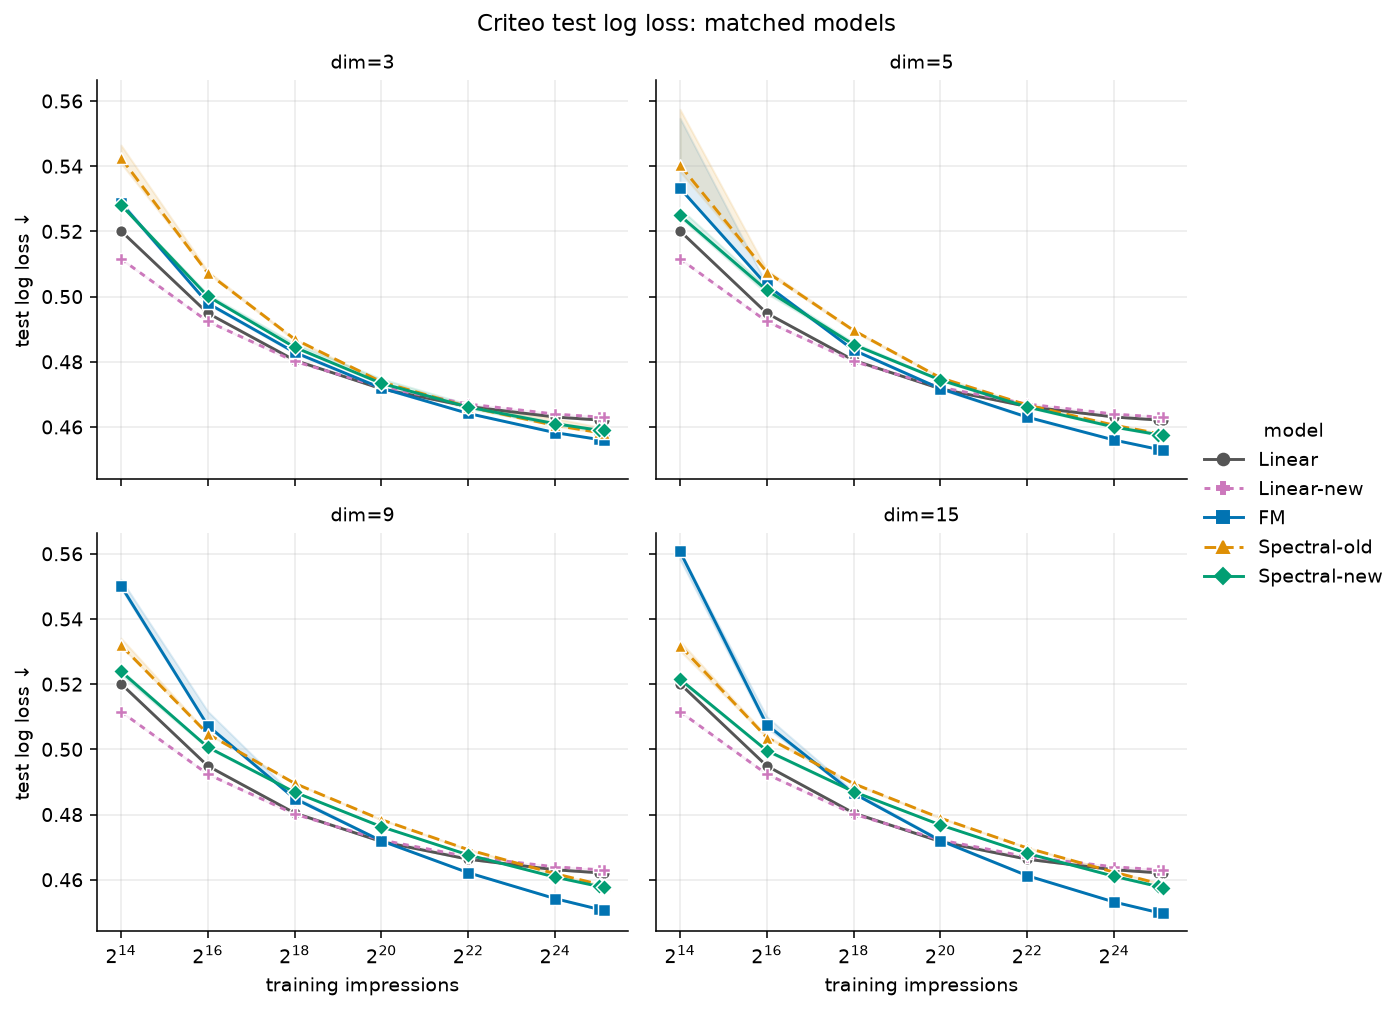

In [5]:
plot_criteo_models_by_dimension(selected, metric=metric);

## Spectral preprocessing within each dimension

This view removes the linear and FM references to isolate the effect of the numerical representation.

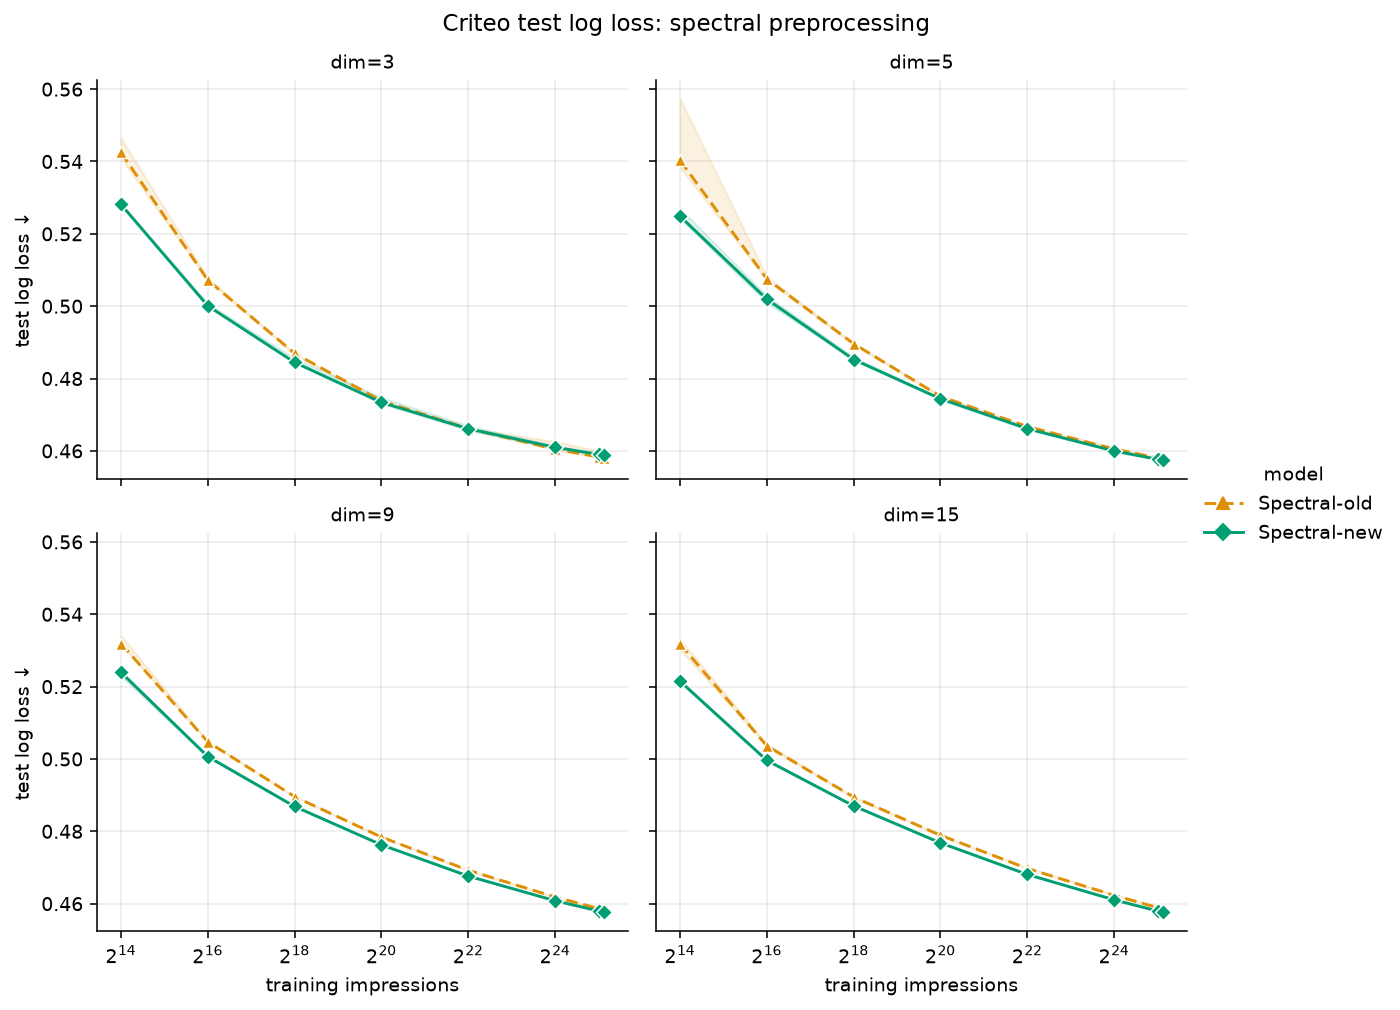

In [6]:
plot_criteo_spectral_comparison(selected, metric=metric);

## Spectral-new across dimensions

All hybrid-preprocessed spectral capacities on one axis.

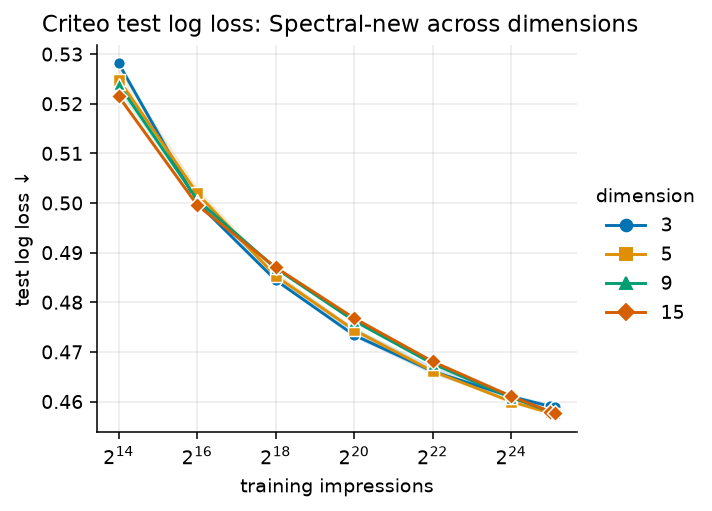

In [7]:
plot_criteo_spectral_dimensions(
    selected, "spectral-new", metric=metric
);

## Spectral-old across dimensions

All bucket-preprocessed spectral capacities on one axis.

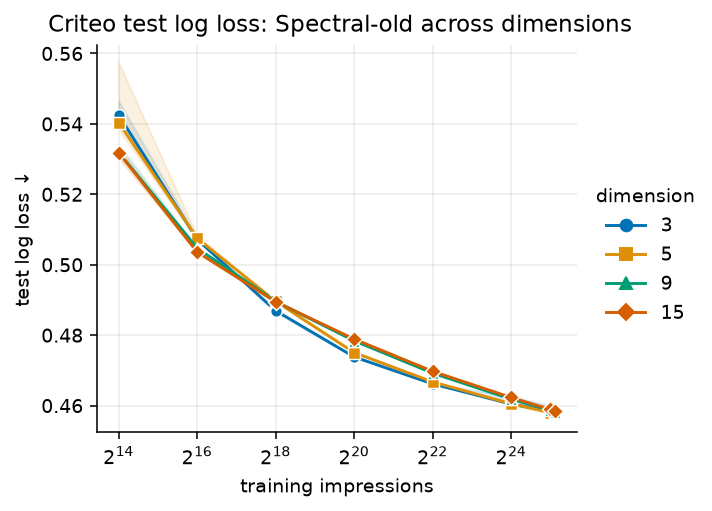

In [8]:
plot_criteo_spectral_dimensions(
    selected, "spectral-old", metric=metric
);

## Reading the comparison

The first two figures hold dimension fixed, so old and new spectral neurons have the same matrix parameter count. The last two figures hold preprocessing fixed, making the effect of increasing spectral dimension visible. Lines are medians across seeds and bands span the 25th to 75th percentiles. Change `metric` in Setup to `"brier"` for the corresponding Brier-score views.